In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Zomato data .csv")
print(df)
#Data Cleaning

def handleRate(value):
    value = str(value).split('/')
    value = value[0];
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
print(df.head())


                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [3]:
#checking null values
df.info()
#Types of Resturant
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'Types of Resturant')

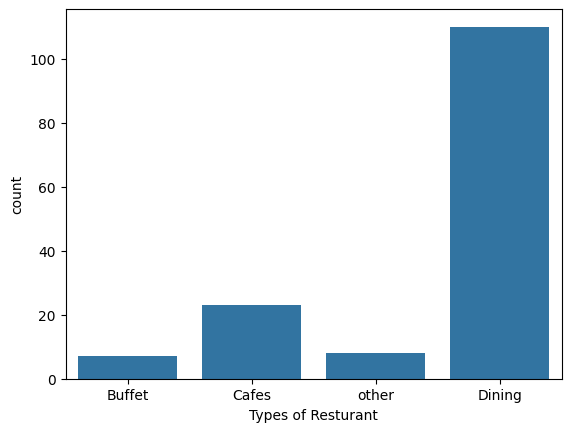

In [4]:
#Data Visualization
#1. What types of resturant do the majority of customers order from?
sns.countplot(x = df['listed_in(type)'])
plt.xlabel('Types of Resturant')

In [5]:
#Conclusion: Majority of the Resturant falls under Dining Category.

Text(0, 0.5, 'votes')

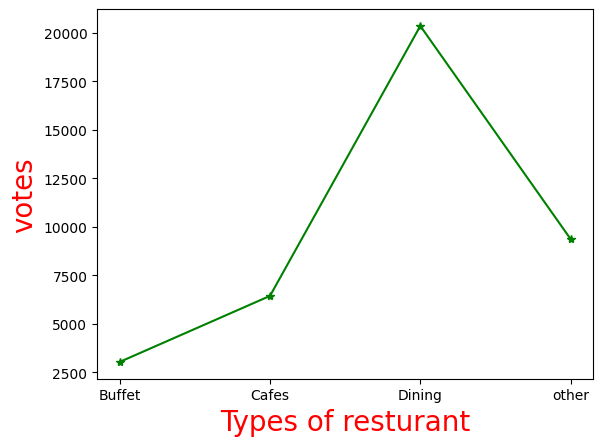

In [6]:
#2. How many votes has each type of Resturant received from customers?
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})
plt.plot(result, c="green",marker="*")
plt.xlabel("Types of resturant", c="red", size=20)
plt.ylabel("votes", c= "red", size=20)

In [7]:
#Conclusion: Dining type of resturant have received the most votes from customer.

In [8]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


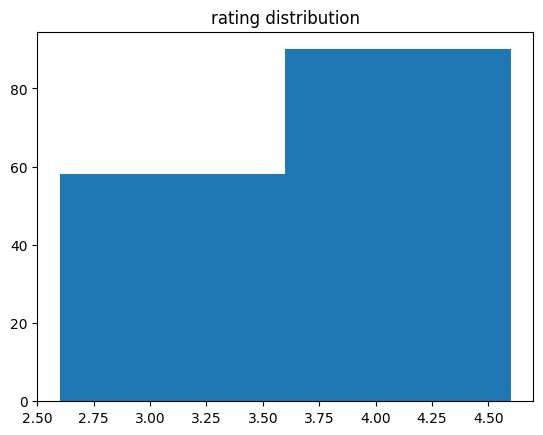

In [9]:
#What are the rating that majority of the resturants have received?
plt.hist(df['rate'],bins=2)
plt.title('rating distribution')
plt.show()

In [10]:
#Conclusion: majority of the Resturant have received rating from 3.5 to 4.5

In [11]:
#4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

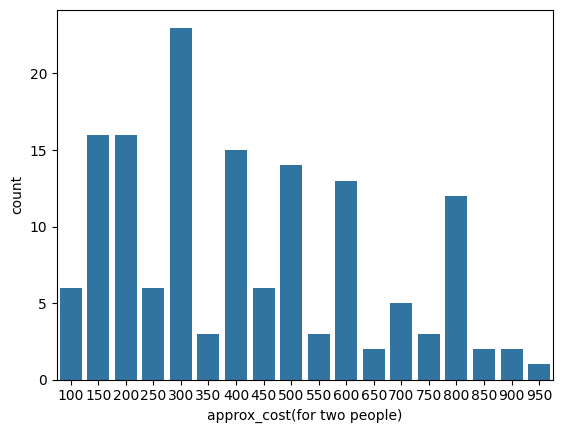

In [12]:
couple_data= df['approx_cost(for two people)']
sns.countplot(x = couple_data)

In [13]:
#conclusion- Majority of the couple prefer restrurant with an approx cost of 300 rupees.

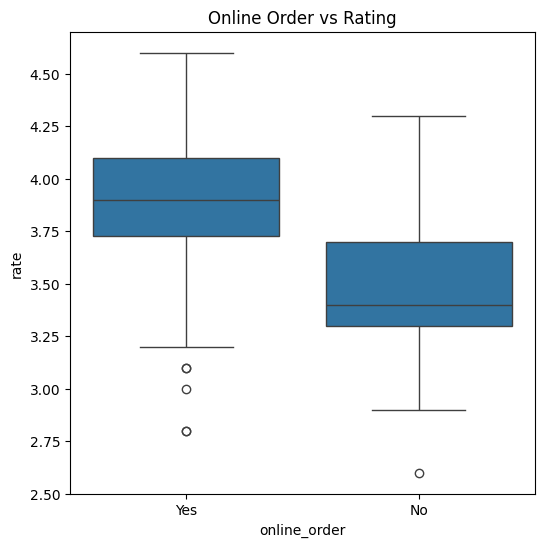

In [14]:
# 5. Which mode (online or offline) has received maximum rating?
plt.figure(figsize=(6, 6))
sns.boxplot(x="online_order", y="rate", data=df)
plt.title("Online Order vs Rating")
plt.show()


In [15]:
#Conclusion:Online order has received maximum rating compared to Offline order

In [16]:
#6. Which type of resturant received more offline orders, so that Zomato can approach customer with some more good offers?
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


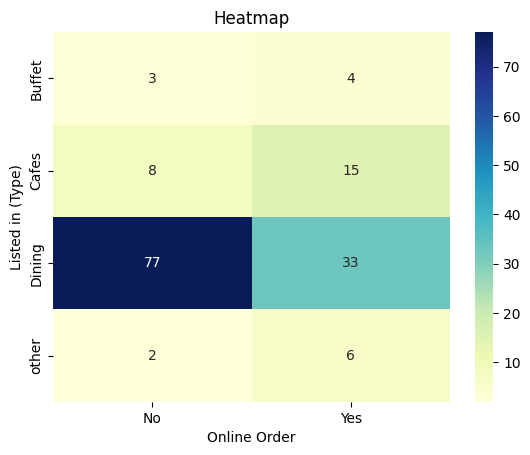

In [17]:
pivot_table = df.pivot_table(
    index="listed_in(type)",
    columns="online_order",
    aggfunc="size",
    fill_value=0
)

sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')

plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed in (Type)")
plt.show()